# Life Expectancy by GDP for Six Distinct Countries 

This project will investigate the correlation of GDP on Life Expectancy for six different countries: 

Chile \
China \
Germany \
Mexico \
United States of America \
Zimbabwe 

Some of the preliminary questions this analysis will attempt to answer include: 

- Has life expectancy increased over time in the six nations?
- Has GDP increased over time in the six nations?
- Is there a correlation between GDP and life expectancy of a country?
- What is the average life expectancy in these nations?
- What is the distribution of that life expectancy?

## Import Data & Set Preliminary Functions

Import data and Python modules for analysis. Print the data set.  

In [99]:
import numpy as np
import pandas as pd 
from matplotlib import pyplot as plt 
import seaborn as sns 

all_data = pd.read_csv('all_data.csv')

### Formatting Function 

This function is used to format the GDP values into a more readable form (i.e. \$ USD Billion/Trillion)

In [298]:
# Function used to format GDP values 
def format_axes(input_list, scale):
    list_gdp = input_list
    formatted_list = []
    scale = scale.lower()
    if scale == 'billion':
        for item in list_gdp: 
            if (item >= 10**9):
                formatted_list.append(f"${item / 10 ** 9:,.0f} B")
            else: 
                item = '$ 0'
                formatted_list.append(item)
    if scale == 'trillion':
        for item in list_gdp: 
            if (item >= 10**12):
                formatted_list.append(f"${item / 10 ** 12:,.1f} T")
            elif (item >= 10**9):
                formatted_list.append(f"${item / 10 ** 12:,.1f} T")
            else: 
                item = '$ 0'
                formatted_list.append(item)
    return formatted_list

## Data Exploration 

In [299]:
all_data.head()

,Country,Year,Life_Expectancy,GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


One of the columns is inconveniently named "Life expectancy at birth (years)". We should change this to a more accessible name e.g., "Life_Expectancy" 

In [300]:
all_data = all_data.rename(columns={'Life expectancy at birth (years)' : 'Life_Expectancy'})
all_data.head()

,Country,Year,Life_Expectancy,GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


In [301]:
print(f'\nThere are {all_data.index.max()+1} rows and {len(all_data.columns)} columns - ({all_data.index.max()+1}x{len(all_data.columns)})')

print(f"\nWith {all_data['Country'].nunique()} unique countries: ")

for country in list(all_data['Country'].unique()):
    print('     -', country)

print('')
print(f"\nSpanning a total of {all_data['Year'].nunique()} years: ")
print(list(all_data['Year'].unique()))

print('')


There are 96 rows and 4 columns - (96x4)

With 6 unique countries: 
     - Chile
     - China
     - Germany
     - Mexico
     - United States of America
     - Zimbabwe


Spanning a total of 16 years: 
[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015]



## Summary Statistics

In [302]:
summary_stat = all_data.describe()
summary_stat = summary_stat.drop('Year', axis=1)

# Obtain the columns for formatting 
gdp_list = list(summary_stat['GDP'])
age_list = list(summary_stat['Life_Expectancy'])
age_list = [round(item, 2) for item in age_list]

# Format the GDP values to $USD billion
gfp_formatted_list = format_axes(gdp_list, 'billion')
summary_stat['GDP'] = gfp_formatted_list
summary_stat['Life_Expectancy'] = age_list
summary_stat.iloc[0,1] = 96
summary_stat

,Life_Expectancy,GDP
count,96.00,96
mean,72.79,"$3,880 B"
std,10.67,"$5,198 B"
min,44.30,$4 B
25%,74.47,$173 B
50%,76.75,"$1,280 B"
75%,78.90,"$4,068 B"
max,81.00,"$18,100 B"


In [336]:
print('Life_Expectancy')
print('-'*len('Life_Expectancy'))
print(f"mean: {round(all_data['Life_Expectancy'].mean(), 2)}")
print(f"median: {all_data['Life_Expectancy'].median()}")
print(f"mode: {all_data['Life_Expectancy'].mode()[0]}")
print('-'*len('Life_Expectancy'))
print('')

print('GDP')
print('-'*len('GDP'))
print(f"mean: {round(all_data['GDP'].mean(), 2)}")
print(f"median: {all_data['GDP'].median()}")
print(f"mode: {all_data['GDP'].mode()[0]}")
print('-'*len('GDP'))
print('')

Life_Expectancy
---------------
mean: 72.79
median: 76.75
mode: 75.0
---------------

GDP
---
mean: 3880498570768.4
median: 1280220000000.0
mode: 4415702800.0
---



### Summary Statistics Analysis

The summary statistics shows a decoupling of economic scales and expected lifespan. While the GDP values vary by several orders of magnitude, life expectancy remains somewhat stable, suggesting that massive financial growth does not translate to gains in lifespan in majority of cases.   

The tight four-year gap between the 25th and 75th percentile (74.5 and 79 years) indicate most nations in this set cluster around the median (76-77 years). We note that the average life expectancy in our dataset is approx. 73 years, with a stdev of \~11 years. The large stdev is largely driven by the bottom tail of the distribution - minimum (44 years). This tail is significantly further away from the median (\~77 years) than the maximum (81 years). The low values \~44 pull the mean down to a lower age. 

In contrast, the GDP data is spread is both directions (right-tail and left-tail). The average GDP (\~\\$3.9 Trillion USD) is nearly 3x the median (\\$1.28 Trillion USD). High-value outliers have a much higher impact on the mean, pulling it higher. \
The massive spread between the 25th percentile (\~\\$0.173 Trillion USD) and 75th percentile (\~\\$4.1 Trillion USD) highlights that the middle of this dataset contains a vast number of GDP values. This reality is reflected by the large st dev of  GDP values (\\$5.2 Trillion USD). The max value \\$18 Trillion USD is more than 40x greater than the minimum value. The mean is largely impacted by these outliers (min/max), with a median of \\$1.28 Trillion USD. 

These statistics show that while the GDP is highly skewed, life expectancy is significantly more consistent for majority of observations. This analysis suggests diminished returns - moving from the 25th to 75th percentile of wealth involves nearly a 24-fold increase in GDP, but only results in a 5\% increase in life expectancy.

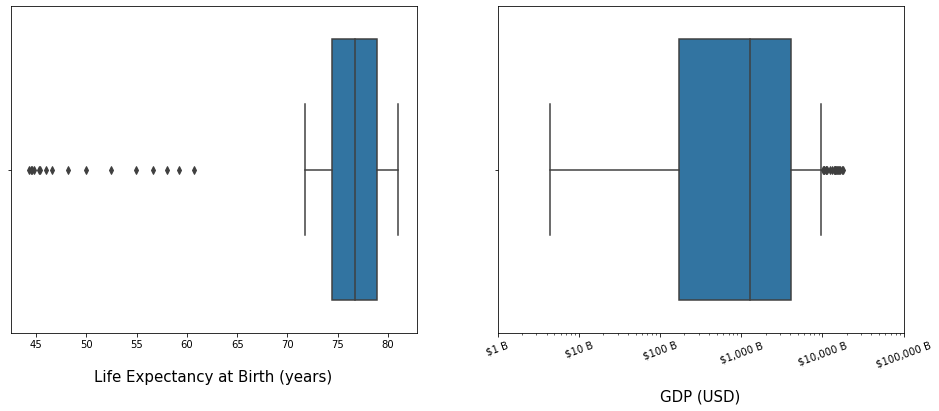

In [304]:
fig, ax = plt.subplots(1, 2, figsize=(16,6));

sns.boxplot(x='Life_Expectancy', data=all_data, ax=ax[0]);
ax[0].set_xlabel('Life Expectancy at Birth (years)', labelpad=20, size=15);

sns.boxplot(x='GDP', data=all_data, ax=ax[1]);
ax[1].set_xlabel('GDP (USD)', labelpad=20, size=15);
ax[1].set_xscale('log')
lst_xticks = list(ax[1].get_xticks());
list_xticks_formatted = format_axes(lst_xticks, 'billion')
ax[1].set_xticks(lst_xticks[1:-1]);
ax[1].set_xticklabels(list_xticks_formatted[1:-1]);
ax[1].tick_params(axis='x', rotation=20)

The boxplots highlight some of the contrast between Life Expectancy and GDP that we saw from the summary statistics. For the left boxplot (Life Expectancy), the data is left-skewed, with a tight concentration between 74 - 79 years. There are several low-end outliers, meaning the mimima we saw in the summary statistics table is more than simply a fluke. This pulls the mean significantly below the median. However, if we remove these outliers, the average life expectancy would be very close to the mean and we see little spread to this data outside of these outliers. Since there are ~10-15 outliers on the boxplot, these are likely contirbuted by a single country with lower life expectancy. 

In contrast, the log-scale GDP boxplot reveals a vast range for the middle 50% of the dataset, spanning between \\$150 billion to \\$4,000 billion (\\$4 trillion). There is a significant number of outliers to the right, making this distribution much more right-skewed, showing there are outlier nations with massive GDPs.  

While GDP spans several orders of magnitude, life expectancy for nearly all nations remains stable and clustered near the median. Despite the broad economic spread, there appears to be a sharp ceiling to life expectancy. 

In [305]:
print(lst_xticks[1:-1])
print(list_xticks_formatted[1:-1])

[1000000000.0, 10000000000.0, 100000000000.0, 1000000000000.0, 10000000000000.0, 100000000000000.0]
['$1 B', '$10 B', '$100 B', '$1,000 B', '$10,000 B', '$100,000 B']


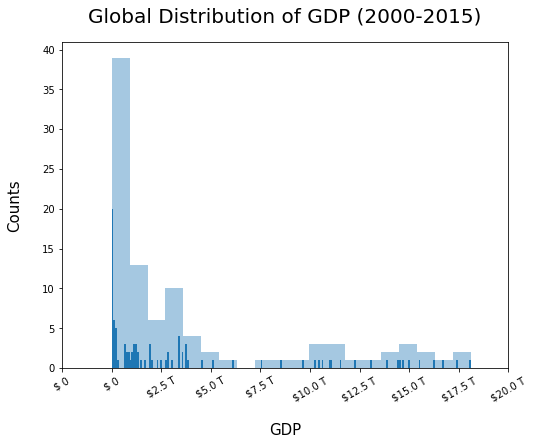

In [306]:
fig, ax = plt.subplots(figsize=(8,6));

plt.hist(all_data['GDP'], bins=200, color='tab:blue');
plt.hist(all_data['GDP'], bins=20, alpha=0.4, color='tab:blue');
axes = list(ax.get_xticks());
formatted_axes = format_axes(axes, 'trillion');
ax.set_xticks(axes);
ax.set_xticklabels(formatted_axes);
ax.tick_params(axis='x', rotation=30)

plt.xlabel('GDP', labelpad=20, size=15);
plt.ylabel('Counts', labelpad=20, size=15);
plt.title('Global Distribution of GDP (2000-2015)', pad=20, size=20);

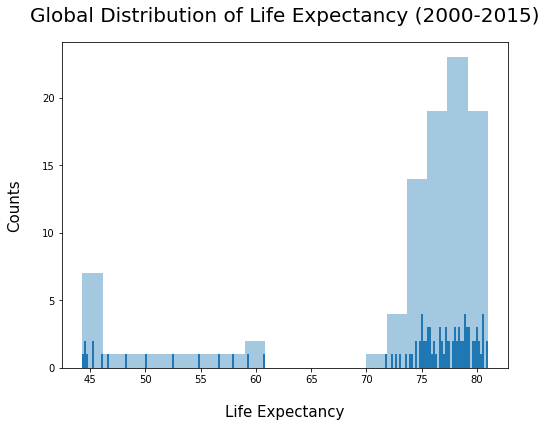

In [335]:
fig, ax = plt.subplots(figsize=(8,6));

plt.hist(all_data['Life_Expectancy'], bins=200, color='tab:blue');
plt.hist(all_data['Life_Expectancy'], bins=20, color='tab:blue', alpha=0.4);

plt.xlabel('Life Expectancy', labelpad=20, size=15);
plt.ylabel('Counts', labelpad=20, size=15);
plt.title('Global Distribution of Life Expectancy (2000-2015)', pad=20, size=20);

Life expectancy has a strong left-skew as seen in the boxplot. The median and mode are close to each and support the idea that majority of observations cluster together in the high end of the age scale. 

The GDP distribution is severely right-skewed. The mean (//$3.88 trillion) is nearly 3x the median (\\$1.28 Trillion). Some high output economies influence the global average, while the majority of observations exist at a much lower economic scale.  

In [337]:
# Group data by Country 
test = all_data.groupby('Country')

In [338]:
average_gdp = all_data.groupby('Country')['GDP'].mean().reset_index()
average_age = all_data.groupby('Country')['Life_Expectancy'].mean().reset_index()

countries = list(average_age['Country'])
countries_list = [item.replace('United States of America', 'USA') for item in countries]

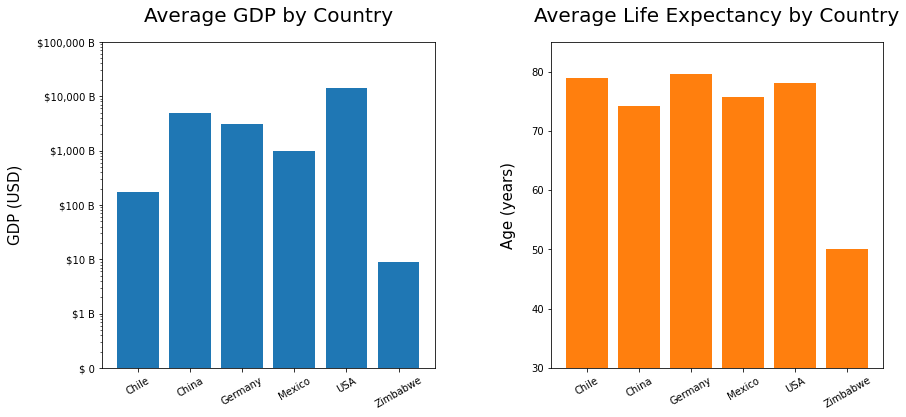

In [339]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].bar(average_gdp['Country'], average_gdp['GDP'])
ax[0].set_yscale('log')
ax[0].tick_params(axis='x', rotation=30);
ax[0].set_ylabel('GDP (USD)', labelpad=15, size=15)

# Format the y-ticks to show $USD in Billions 
ticks = ax[0].get_yticks()
formatted_ticks = format_axes(ticks, 'billion')

ax[0].set_yticks(ticks[:-1])
ax[0].set_yticklabels(formatted_ticks[:-1])

# Set formatted country labels 
ax[0].set_xticks(average_gdp['Country']);
ax[0].set_xticklabels(countries_list);
ax[0].set_title('Average GDP by Country', pad=20, size=20);

ax[1].bar(average_age['Country'], average_age['Life_Expectancy'], color='tab:orange');
ax[1].tick_params(axis='x', rotation=30);
ax[1].set_xticks(average_gdp['Country']);
ax[1].set_xticklabels(countries_list);
ax[1].set_ylabel('Age (years)', labelpad=15, size=15);
ax[1].set_ylim(30, 85);
ax[1].set_title('Average Life Expectancy by Country', pad=20, size=20);

plt.subplots_adjust(wspace=0.35)

This aggregate data suggests that GDP is not a linear predictor of life expectancy across most nations. For example, Chile matains a life expectancy that is three-five years higher than Mexico's despite having only about 20% of Mexico's total GDP. 

A similar trend is visible when comparing China and Germany. Although China's GDP is approximately 1.5 times larger than Germany's, its life expectancy remains lower by three-five years. This discrepancy highlights that total national wealth does not translate to superior health outcomes, likely due to differences in population size and distribution of resources.

The relationship may change when looking at developing nations such as Zimbabwe, but this data set lacks depth to test this hypothesis. In these context, initial increases in GDP may translate to gains in life expectancy by addressing basic needs such as sanitation, nutrition, health care and eductation. However, as nations develop beyond these baseline necessities, gains in wealth plateau, suggesting wealth is distributed among certain socioeconomic groups and is not contributing to the broader population. Other factors in longevity in countries that have developed basic necessities are likely driven by lifestyle factors, healthcare efficiency, culutral and social components rather than simple economic reach. 

This becomes most evident when comparing USA and Chile. We see the USA GDP is nearly 80 times greater than Chile, yet both countries report similar life expectancy figures. This indicates beyond a certain baseline economic threshold, additional economic growth provides diminishing returns for improvements in longevity for the broader population.  

## Growth Trends by Country

In [320]:
list_years = list(all_data['Year'].unique())
years = []

for year in list_years:
    if year % 2 == 0:
        years.append(str(year))
    else:
        years.append('')
        
colors = np.array([['gray', 'red', 'black'], 
                 ['tab:green', 'tab:blue', 'tab:orange']])

In [321]:
age_dict = {}
gdp_dict = {}

for name, group in test:
    max_age = group['Life_Expectancy'].max()
    min_age = group['Life_Expectancy'].min()
    avg_age = round(group['Life_Expectancy'].mean(), 2)
    delta_age = abs(group.iloc[0,2] - group.iloc[-1,2])
    age_list = [max_age, min_age, avg_age, delta_age]
    
    max_gdp = group['GDP'].max()
    min_gdp = group['GDP'].min()
    avg_gdp = round(group['GDP'].mean(), 2)
    delta_gdp = abs(group.iloc[0,3] - group.iloc[-1,3])
    gdp_list = [max_gdp, min_gdp, avg_gdp, delta_gdp]
    gdp_list_formatted = format_axes(gdp_list, 'billion')
    
    age_dict[name] = age_list
    gdp_dict[name] = gdp_list_formatted

In [322]:
index_list = ['max.', 'min.', 'avg.', 'diff']


aggregate_age_data = pd.DataFrame(age_dict)
aggregate_age_data.index = index_list

aggregate_gdp_data = pd.DataFrame(gdp_dict)
aggregate_gdp_data.index = index_list

In [345]:
aggregate_age_data

,Chile,China,Germany,Mexico,United States of America,Zimbabwe
max.,80.50,76.10,81.00,76.70,79.30,60.70
min.,77.30,71.70,78.00,74.80,76.80,44.30
avg.,78.94,74.26,79.66,75.72,78.06,50.09
diff,3.20,4.40,3.00,1.90,2.50,14.70


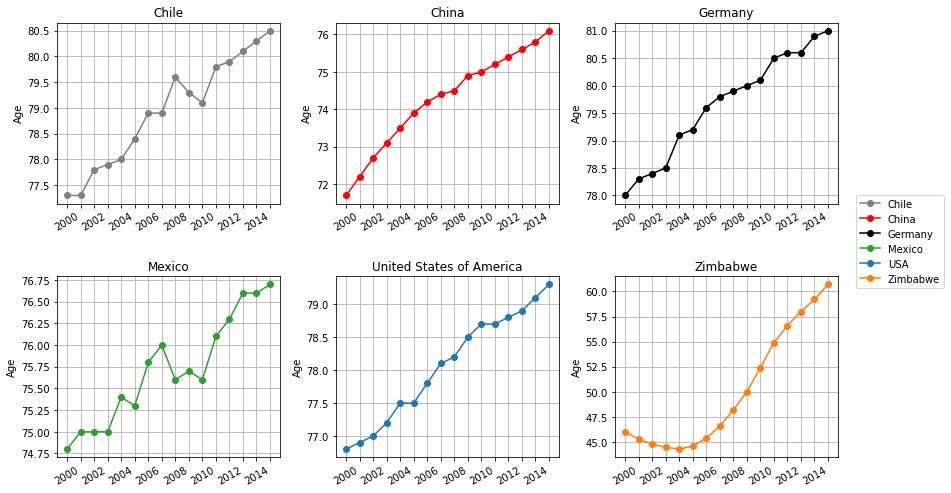

In [340]:
fig, ax = plt.subplots(2, 3, figsize=(14,8))    

i = 0
j = 0

for name, group in test:
    c = colors[i,j]
    ax[i,j].plot(group['Year'], group['Life_Expectancy'], color=c, marker='o')
    ax[i,j].set_ylabel('Age')
    ax[i,j].set_title(f'{name}')
    ax[i,j].set_xticks(group.Year.unique())
    ax[i,j].set_xticklabels(years)
    ax[i,j].tick_params(axis='x', rotation=30)
    ax[i,j].grid(True)
    j += 1
    if j > 2:
        j = 0
        i += 1
        
plt.subplots_adjust(wspace=0.25, hspace=0.4);
fig.legend(countries_list, loc='center right', bbox_to_anchor=(1.01, 0.5));

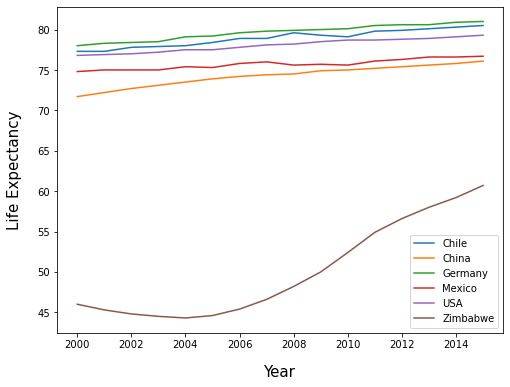

In [344]:
fig, ax = plt.subplots(figsize=(8,6));

for name, group in test: 
    ax.plot(group['Year'], group['Life_Expectancy'])

plt.legend(countries_list);
plt.xlabel('Year', size=15, labelpad=15);
plt.ylabel('Life Expectancy', size=15, labelpad=15);

Life expectnacy increased linearly over time for all six nations over the 15 year period: 

Chile : + 3 years \
China : + 4 years \
Germany : + 3 years \
Mexico : + 2 years \
USA : + 2.5 years \
Zimbabwe : + 15 years  

Mexico shows the smallest increase in Life Expectancy over 15 years, with periods of peaks and throughs - e.g., life expectancy declined by 0.5 year between 2007 and 2010 and sharply increased by 2011. 

Zimbabwe's life expectancy declined from 2000 - 2004, reaching a minimum and then spiking rapidly. China saw the most consistent growth, growing at a rate of about 0.25 (+life expectancy) per year. 

Global life expenctancy seems to have declined twice, with several countries showing flattening between 2001 - 2003 and another flattened period between 2008 - 2010.

In [325]:
aggregate_gdp_data

,Chile,China,Germany,Mexico,United States of America,Zimbabwe
max.,$278 B,"$11,065 B","$3,891 B","$1,298 B","$18,100 B",$16 B
min.,$70 B,"$1,211 B","$1,950 B",$684 B,"$10,300 B",$4 B
avg.,$170 B,"$4,958 B","$3,095 B",$977 B,"$14,075 B",$9 B
diff,$165 B,"$9,853 B","$1,426 B",$469 B,"$7,800 B",$10 B


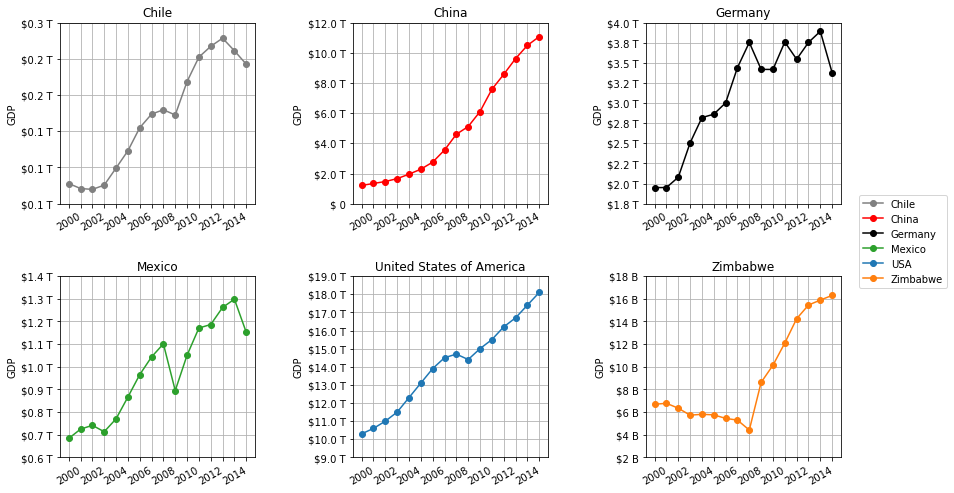

In [326]:
fig, ax = plt.subplots(2, 3, figsize=(14,8))    

i = 0
j = 0

for name, group in test:
    # Find condition for axes formatting 
    temp_array = np.array(group['GDP'])
    if temp_array[0] > 10*(10**9):
        condition = 'trillion'
    else: 
        condition = 'billion'
        
    # Find colour in the colour matrix 
    c = colors[i,j]
    
    # Create plot in the correct axis 
    ax[i,j].plot(group['Year'], group['GDP'], color=c, label=f'{name}', marker='o')
    ax[i,j].set_ylabel('GDP')
    ax[i,j].set_title(f'{name}')
    ax[i,j].set_xticks(group.Year.unique())
    ax[i,j].set_xticklabels(years)
    ax[i,j].grid(True)
    
    # Format y-axis
    lst = list(ax[i,j].get_yticks())
    formatted_list = format_axes(lst, condition)
    ax[i,j].set_yticks(lst)
    ax[i,j].set_yticklabels(formatted_list)
    
    # Rotate x-ticks for better display
    ax[i,j].tick_params(axis='x', rotation=30)
    
    # Change coordinates for grid and colour matrix 
    j += 1
    if j > 2:
        j = 0
        i += 1

# Aesthetic changes - subplot adjustments and legend location
plt.subplots_adjust(wspace=0.5, hspace=0.4);
fig.legend(countries_list, loc='center right', bbox_to_anchor=(1.01, 0.5));

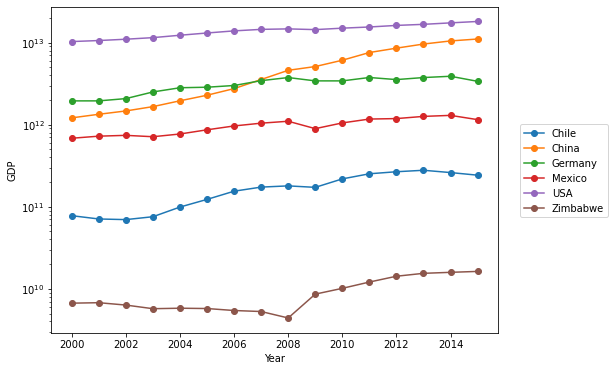

In [347]:
fig, ax = plt.subplots(figsize=(8,6));

for name, group in test: 
    ax.plot(group['Year'], group['GDP'], marker='o')

ax.set_yscale('log')
plt.xlabel('Year');
plt.ylabel('GDP');
fig.legend(countries_list, loc='center right', bbox_to_anchor=(1.1, 0.5));

In [352]:
aggregate_gdp_data

,Chile,China,Germany,Mexico,United States of America,Zimbabwe
max.,$278 B,"$11,065 B","$3,891 B","$1,298 B","$18,100 B",$16 B
min.,$70 B,"$1,211 B","$1,950 B",$684 B,"$10,300 B",$4 B
avg.,$170 B,"$4,958 B","$3,095 B",$977 B,"$14,075 B",$9 B
diff,$165 B,"$9,853 B","$1,426 B",$469 B,"$7,800 B",$10 B


GDP increased for all six nations over the 15 year period. The approximate increases by nation are outlined below:

Chile : \\$0.165 T \
China : \\$10 T \
Germany : \\$1.5T \
Mexico : \\$0.5T \
USA : \\$7.8T \
Zimbabwe : \\$0.01T 

While all countries saw increases in GDP, suggesting a global trend, there are vast differences between certain nations, showcasing tiers of economic prosperity. \
Starting from the low end, Zimbabwe sees a growth factor that is about 16x smaller than Chile, and 50x smaller than Mexico showcasing a huge gap between these two \
economic worlds. Comparably, Germany sees growth about 10x faster than Chile, and about 3x faster than Mexico. Germany's growth factor is 140x larger than Zimbabwe. 

Finally, looking at the high-end outliers, China and US boast massive growth factors, which are nearly an order of magnitude greater than prosperous nations such as \
Germany. Thes growth factors are 1,000x greater than the growth factors we see in Zimbabwe, demonstarting the massive disparity not only in the current economic capabilities \
of third/fourth-world nations, but the economic supremacy of the world's most powerful nations. 

One thing that stands out, is China's meteoric rise to world superpower in a short 10 year span. From the line graph we can see that up to 2006, China had a lower GDP than Germany, \
and over a decade it saw nearly 10-fold increase in it's GDP. 

When we look at the absolute numbers, USA and China are 1,000x more properous than countries like Zimbabwe, 100x more porperous than South American nation of Chile, and about \
10x more properous than Mexico and Germany. 

This line chart suggests there are four tiers to economic prowess based on powers of \\$10T - first tier (\\$10T), second tier (\\$1T), third-tier (\\$0.1T), fourth-tier (\\$0.01T). 

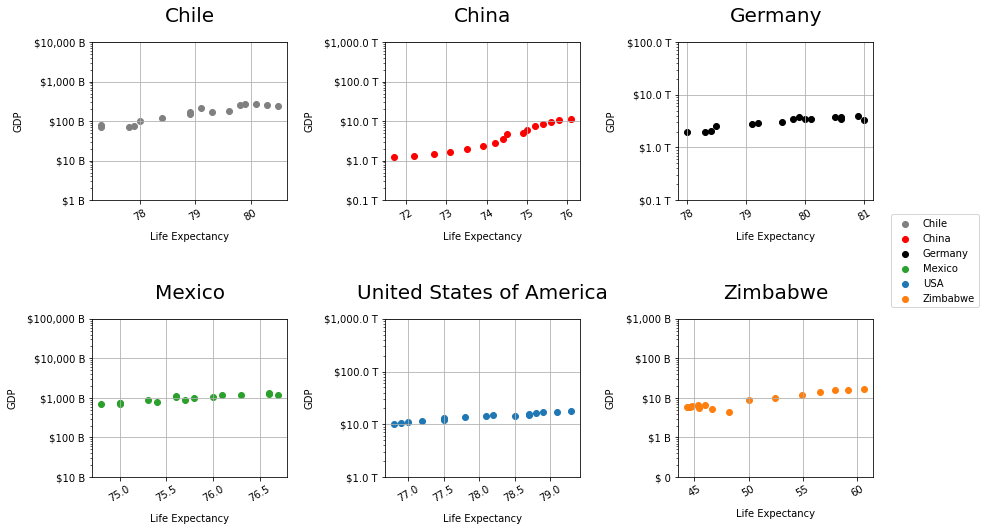

In [327]:
fig, ax = plt.subplots(2, 3, figsize=(14,8))    

i = 0
j = 0

for name, group in test:
    # Find condition for axes formatting 
    temp_array = np.array(group['GDP'])
    if temp_array[0] > (10**12):
        condition = 'trillion'
    else: 
        condition = 'billion'
    
    
    c = colors[i,j]
    ax[i,j].scatter(group['Life_Expectancy'], group['GDP'], color=c, label=f'{name}', marker='o')
    ax[i,j].set_yscale('log')
    ax[i,j].set_ylabel('GDP', labelpad=10)
    ax[i,j].set_xlabel('Life Expectancy', labelpad=10)
    ax[i,j].set_title(f'{name}', size=20, pad=20)
    ax[i,j].grid(True)
    
    lst = list(ax[i,j].get_yticks())
    formatted_list = format_axes(lst, condition)
    
    ax[i,j].set_yticks(lst)
    ax[i,j].set_yticklabels(formatted_list)
    
    ax[i,j].tick_params(axis='x', rotation=30)
    
    j += 1
    if j > 2:
        j = 0
        i += 1
        
plt.subplots_adjust(wspace=0.5, hspace=0.75);
fig.legend(countries_list, loc='center right', bbox_to_anchor=(1.01, 0.5));

# Discussion

A critical takeaway from this analysis is the significant "decoupling" of national wealth and human longevity. The data suggests that GDP growth has a negligible impact on life expectancy, and while GDP grew annually on a global basis, life expectancy grew independently, and is not driven by the GDP growth. Chile exemplifies this, maintaining a life expectancy equal to or higher than the USA and China despite having an economy approximately $1/65$th the size. Similarly, Mexico with a GDP five times larger than Chile’s, sees life expectancy that is three years lower, reinforcing the idea that financial scale does not translate to proportional gains in lifespan. 

The most compelling evidence for this decoupling is found in Zimbabwe's trajectory. Between 2004 and 2008, Zimbabwe’s GDP contracted by nearly $30\%$, dropping by approximately $\$2$ billion, yet life expectancy increased by an astonishing three years during this same period. This inverse relationship strongly suggests that health improvements were driven by targeted interventions—such as addressing disease, famine, or war—rather than economic prosperity. This "explosion" in life expectancy represents a return to a natural baseline as premature mortality among younger populations was mitigated, allowing the nation to trend back toward the global median.

Across the entire dataset, the consistent 2-to-4-year gain in life expectancy observed between 2000 and 2015 likely stems from global advances in medicine and public health rather than the simultaneous 2-to-4-fold increase in global GDP. While economic growth is often cited as a driver of development, these findings indicate that it is a secondary factor compared to medical and social advancements. Ultimately, the data confirms that for most nations, human longevity is governed by a biological ceiling that remains remarkably stable regardless of exponential economic expansion.

# Conclusion

### Addressing the preliminary questions:

- <b> Has life expectancy increased over time in the six nations? </b> \
Yes, life expectancy ubcreased across all six nations, throughout the 15 year period of this study. \
While most countries showed steady growth, Zimbabwe experienced a notable decline, reaching a minimum around 2004, and a sbusequent boom in life expectancy.  

- <b> Has GDP increased over time in the six nations? </b> \
Yes, GDP also increased in eery nation analyzed over the 15 year period. However, these scales of growth vary much more drastically than life expectancy. \
The USA and China show largest absolute growth that is 100-1000's of time greater than other nations. The economic trend suggests multiple tiers of economic progress, \
which does not directly correlate to life expectancy. 

- <b> Is there a correlation between GDP and life expectancy of a country? </b> \
There appears to be a correlation between GDP and life expectancy, however, this trend is non-linear, as gains in longevity become much smaller as countries reach higher levels \
of wealth. Chile serves as the perfect example of this phenomena; despite having a GDP that is about 1/100 of the USA's or China's, it has reached the same approximate life expectancy \
of 80 years. This discrepancy highlights that once a nation meets basic needs like infrastructure, nutrition, and healthcare access, adding trillions of dollars in additional GDP does \
not extend the human lifespan. The data suggests that the correlation is most influential at the lower end of the economic spectrum. For wealthy nations, factors other than raw GDP \
—such as lifestyle, diet, or healthcare efficiency—likely play a much larger role in pushing life expectancy those final few years toward the maximum.

- <b> What is the average life expectancy in these nations? </b> \
The average life expectancy across the entire dataset is approximately $72.79$ years. The median is slightly higher at $76.75$ years.

- <b> What is the distribution of that life expectancy? </b> \
The distribution of life expectancy is heavily left-skewed. Most observations cluster between $74$ and $81$ years, but the mean is pulled lower by significant outliers, primarily \
from Zimbabwe reaching as low as $44.3$ years. Although Zimbabwe sees smallest GDP, it's lowest life expectancy does not correlate to it's lowest GDP. In fact, the lowest point \
in Zimbabwe's GDP occured around 2008, when the countries life expectancy was seeing some of it's most rapid growth. Their lowest life expectancy might be due to disease crisis, \
war or famine, rather than raw GDP. 


### Additional Take-Aways: 
- Expected Results: \
The general upward trend in both metrics was expected, but the severity of the wealth gap—where one country's GDP is $40$ times larger than another's while their life expectancies \
differ by less than $10\%$—was more extreme than anticipated.

- Key Findings: \
The primary takeaway is the "diminishing returns" of wealth on health. The data confirms that while every nation improved, the biological "ceiling" for human life remains a consistent \
factor regardless of massive financial growth, with social and cultural factors likely having a much greater impact on these metrics. 